<a href="https://colab.research.google.com/github/joplus2/MPA-MLF/blob/main/project/MPA_MLF_projekt_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task description


The project’s task is to classify the number of persons in the room from 60 GHz signal transmission. The dataset consists of snapshots of signals in the delay-Doppler domain that represent the reflections from the targets (human-s/machines) at some distance from the receiver moving with some velocity. To explain, the faster the object moves, the higher the Doppler frequency shifts it generates. The farther from the receiver the person is, the higher the delay it generates. Examples of delay-Doppler snapshots are shown in Fig. 1 for one, two, and three persons in the room.
Note that these examples represent almost ideal records, while noise, reflections, missed targets, etc may distort the
real records. The dataset is created in figures in .png format, where each file represents one two-dimensional snapshot
in the delay-Doppler domain.

The goal is to classify the number of persons present in the room from a given snapshot. Thus, one of the following
four classes may be valid:
- Machine only, zero person in the room
- One person in the room
- Two persons in the room
- Three persons in the room.
\
\
**NOTE: be careful about the numbering. Input images are numbered from 1 and labels from 0**

# Steps

Your task is to make a model for classification on the dataset described above. We do not prescribe the type of ML
model. You can use any architecture we discussed during the semester. Try to achieve the highest testing accuracy
possible. Tune your model’s performance using any techniques we discussed, like Data augmentation, Regularization,
Batch normalisation, etc. You can use any Hyperparameter tunning algorithm to find the best hyperparameters and
the model structure (but it is not required).
On top of the accuracy from Kaggle, try also to investigate how your classifier works for different
classes (zero, one, two, three persons) and, if possible, try to build a classifier working well on all
classes. Check e.g. by confusion matrix, or F1 score for multiclass classification

https://www.kaggle.com/competitions/map-mlf-2026-final-project-czech-and-erasmus-students/leaderboard

## 0. import libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN
from keras.optimizers import SGD, RMSprop, Adam, AdamW, Lion
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import re

## 1. import dataset

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
if ( not os.path.exists("/content/x_train_local/")):

  !cp "/content/drive/MyDrive/MLF_projekt_dataset/x_train.zip" "/content/"

  !mkdir -p "/content/x_train_local/"

  !unzip -q "/content/x_train.zip" -d "/content/x_train_local/"

  !ls -1 "/content/x_train_local/" | wc -l

if ( not os.path.exists("/content/x_test_local/")):

  !cp "/content/drive/MyDrive/MLF_projekt_dataset/x_test.zip" "/content/"

  !mkdir -p "/content/x_test_local/"

  !unzip -q "/content/x_test.zip" -d "/content/x_test_local/"

  !ls -1 "/content/x_test_local/" | wc -l


In [23]:
BASE_DIR = '/content/drive/MyDrive/MLF_projekt_dataset/'
CSV_PATH = os.path.join(BASE_DIR, 'y_train_v2.csv')

# nacteni csv
df_labels = pd.read_csv(CSV_PATH)

# nacitani stitku s +1
df_labels['filename'] = "img_" + (df_labels['id'] + 1).astype(str) + '.png'


In [24]:
batch_size_var = 128

IMAGE_DIR = '/content/x_train_local/'

df_labels['target'] = df_labels['target'].astype(str)

# rozdeleni a normalizace
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

"""
# augumentace - nepouzitelne
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    width_shift_range=0.1,  # Posun na ose X
    height_shift_range=0.1, # Posun na ose Y
    zoom_range=0.1          # Lehký zoom
)
"""

print("trénovací data:")
train_generator = datagen.flow_from_dataframe(
    dataframe=df_labels,
    directory=IMAGE_DIR,
    x_col='filename',
    y_col='target',
    subset='training',
    batch_size=batch_size_var,
    seed=42,
    shuffle=True,
    class_mode='categorical',
    target_size=(128, 113)
)

print("\nvalidační data:")
valid_generator = datagen.flow_from_dataframe(
    dataframe=df_labels,
    directory=IMAGE_DIR,
    x_col='filename',
    y_col='target',
    subset='validation',
    batch_size=batch_size_var,
    seed=42,
    shuffle=False,
    class_mode='categorical',
    target_size=(128, 113)
)

trénovací data:
Found 7382 validated image filenames belonging to 4 classes.

validační data:
Found 1845 validated image filenames belonging to 4 classes.


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, AdaptiveMaxPooling2D, GlobalMaxPooling2D, DepthwiseConv2D

model = Sequential([
    # 1. Konvoluční blok
    #Conv2D(32, (7, 7), activation='relu', input_shape=(128, 113, 3), padding="same"),
    #BatchNormalization(),
    #MaxPooling2D(2, 2),
    # input_shape musí odpovídat target_size z ImageDataGeneratoru (128x128) a 3 barvám (RGB)
    Conv2D(64, (3, 3), activation='relu', input_shape=(128, 113, 3)),
    #BatchNormalization(),
    MaxPooling2D(2, 2),
    #Dropout(0.2),
    # 2. Konvoluční blok
    Conv2D(128, (3, 3), activation='relu'),
    #BatchNormalization(),
    #MaxPooling2D(2, 2),
    #Dropout(0.2),
    # 3. Konvoluční blok
    #Conv2D(256, (3, 3), activation='relu'),
    #MaxPooling2D(2, 2),
    #Conv2D(256, (3, 3), activation='relu', padding="same"),
    #BatchNormalization(),
    #MaxPooling2D(2, 2),
    #Dropout(0.1),
    # Zploštění 2D -> 1D
    Flatten(),
    #GlobalMaxPooling2D(),

    Dense(512, activation='relu'),

    # Dropout náhodně vypne 57 % neuronů při každém kroku - proti přeučení
    Dropout(0.57),
    # jeden sweet spot byla šířka vrstvy 512 a dropout 0,55 + 3x konvolučka bez dropoutu a paddingu

    #Dense(128, activation='relu'),

    # výstupní vrstva pro 4 třídy, softmax pro rozdělení mezi 4 třídy
    Dense(4, activation='softmax')
])

optimizer = Lion(learning_rate = 0.0001)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 111, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 413824)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │   211,878,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,956,100 (808.55 MB)

 Trainable params: 211,956,100 (808.55 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
# vytvoreni slovniku vah
class_weight_dict = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

In [27]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=valid_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/step - accuracy: 0.4209 - loss: 1.2886 - val_accuracy: 0.6358 - val_loss: 0.8358 - learning_rate: 1.0000e-04
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - accuracy: 0.6938 - loss: 0.6389 - val_accuracy: 0.7626 - val_loss: 0.5519 - learning_rate: 1.0000e-04
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.7658 - loss: 0.4794 - val_accuracy: 0.8043 - val_loss: 0.4533 - learning_rate: 1.0000e-04
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.8093 - loss: 0.3991 - val_accuracy: 0.8249 - val_loss: 0.3960 - learning_rate: 1.0000e-04
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.8392 - loss: 0.3360 - val_accuracy: 0.8737 - val_loss: 0.3304 - learning_rate: 1.0000e-04
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.8614 - loss: 0.2977 - val_accuracy: 0.8883 - val_loss: 0.2846 - learning_rate: 1.0000e-04
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 204ms/step - acc

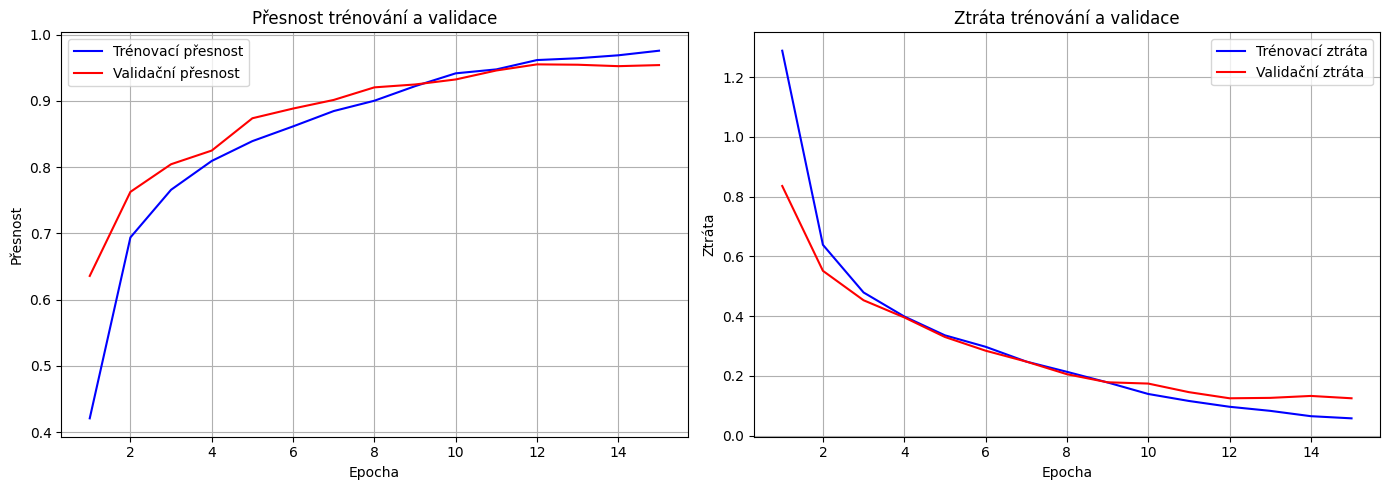

In [28]:

# získání dat z historie tréninku
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# velikosti grafu
plt.figure(figsize=(14, 5))

# přesnost
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Trénovací přesnost')
plt.plot(epochs, val_acc, 'r-', label='Validační přesnost')
plt.title('Přesnost trénování a validace')
plt.xlabel('Epocha')
plt.ylabel('Přesnost')
plt.legend()
plt.grid(True)

# ztráta
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Trénovací ztráta')
plt.plot(epochs, val_loss, 'r-', label='Validační ztráta')
plt.title('Ztráta trénování a validace')
plt.xlabel('Epocha')
plt.ylabel('Ztráta')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step

 Report klasifikace 
                precision    recall  f1-score   support

0 osob (Stroj)       0.99      1.00      0.99       275
       1 osoba       0.96      0.97      0.96       769
       2 osoby       0.95      0.94      0.95       599
       3 osoby       0.88      0.88      0.88       202

      accuracy                           0.96      1845
     macro avg       0.95      0.95      0.95      1845
  weighted avg       0.95      0.96      0.95      1845



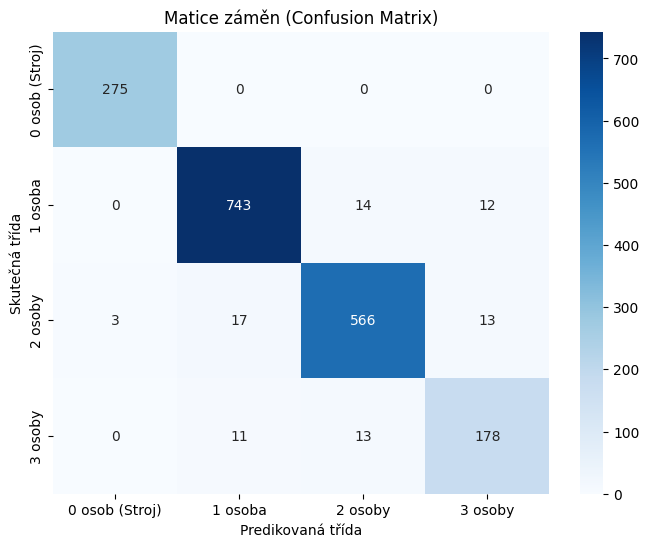

In [29]:
# reset pro čtení od začátku
valid_generator.reset()

Y_pred = model.predict(valid_generator)

# třída s nejvyšší přesností
y_pred = np.argmax(Y_pred, axis=1)

y_true = valid_generator.classes

# presnost
nazvy_trid = ['0 osob (Stroj)', '1 osoba', '2 osoby', '3 osoby']
print("\n Report klasifikace ")
print(classification_report(y_true, y_pred, target_names=nazvy_trid))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nazvy_trid,
            yticklabels=nazvy_trid)
plt.title('Matice záměn (Confusion Matrix)')
plt.ylabel('Skutečná třída')
plt.xlabel('Predikovaná třída')
plt.show()

In [30]:

TEST_DIR = '/content/x_test_local/'

# seznam obrázků
test_files = os.listdir(TEST_DIR)
test_files = [f for f in test_files if f.endswith('.png')]

def extract_number(filename):
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else 0

# serazení
test_files.sort(key=extract_number)

# dataframe pro generátor
test_df = pd.DataFrame({'filename': test_files})

# normalizace
test_datagen = ImageDataGenerator(rescale=1./255)

# načtení testovacích dat
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=TEST_DIR,
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=(128, 113),
    batch_size=batch_size_var,
    shuffle=False
)


# predikce počtu osob
Y_test_pred = model.predict(test_generator)
y_test_pred_classes = np.argmax(Y_test_pred, axis=1)

# vytvoření tabulky
ids = [extract_number(f) - 1 for f in test_files]

submission_df = pd.DataFrame({
    'id': ids,
    'target': y_test_pred_classes
})

# uložení do CSV
submission_df.to_csv('/content/submission.csv', index=False)
print("Soubor vytvořen!")

Found 3955 validated image filenames.
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step
Soubor vytvořen!
